## Setup and Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
# Load the California Housing dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.DataFrame(housing.target, columns=['median_house_value'])

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

display(X.head())
display(y.head())

Features (X) shape: (20640, 8)
Target (y) shape: (20640, 1)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


,median_house_value
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [3]:
# Store latitude and longitude for plotting later
latitude = X['Latitude']
longitude = X['Longitude']

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test, lat_train, lat_test, lon_train, lon_test = train_test_split(
    X_scaled_df, y, latitude, longitude, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

display(X_train.head())

X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512, 1)
y_test shape: (4128, 1)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,-0.321654,0.346478,-0.166259,-0.190451,0.772251,0.059808,-1.367976,1.267645
8267,-0.030620,1.617807,-0.386181,-0.117472,-0.098440,-0.128306,-0.871699,0.703627
17445,0.150349,-1.957806,0.087641,-0.235400,-0.450778,-0.033453,-0.455012,-0.454356
14265,-1.014947,0.584852,-0.576442,-0.132670,-0.006602,0.088940,-1.377340,1.227714
2271,-0.166583,1.141059,0.339282,0.079205,-0.486983,-0.074203,0.537543,-0.114948


In [21]:
display(y_train.head())

,median_house_value
14196,1.030
8267,3.821
17445,1.726
14265,0.934
2271,0.965


## Define Hyperparameters

In [4]:
# Define common hyperparameters
learning_rate = 0.01
epochs = 50
batch_size = 32

# Optimizer (SGD is mandatory)
sgd_optimizer = keras.optimizers.SGD(learning_rate=learning_rate)

## Neural Network Models Definition

In [17]:
# Define the shallow neural network (2 layers)
def def_shallow_model(input_shape, optimizer):
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=[input_shape]),
        layers.Dense(1) # Output layer for regression
    ])
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# Define the deep neural network (4 layers)
def def_deep_model(input_shape, optimizer):
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=[input_shape]),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1) # Output layer for regression
    ])
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# Get the input shape from the training data
input_shape = X_train.shape[1]

# Create model instances with separate optimizers
shallow_optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
deep_optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

shallow_model = def_shallow_model(input_shape, shallow_optimizer)
deep_model = def_deep_model(input_shape, deep_optimizer)

print("Shallow Model Summary:")
shallow_model.summary()

print("\nDeep Model Summary:")
deep_model.summary()

Shallow Model Summary:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

...

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,985 (101.50 KB)

 Trainable params: 25,985 (101.50 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [18]:
# Train the shallow model
print("\nTraining Shallow Model...")
history_shallow = shallow_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1
)

# Train the deep model
print("\nTraining Deep Model...")
history_deep = deep_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1
)


Training Shallow Model...
Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6951 - mae: 0.5247 - val_loss: 0.4952 - val_mae: 0.4765
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5740 - mae: 0.4647 - val_loss: 0.3997 - val_mae: 0.4504
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3969 - mae: 0.4313 - val_loss: 0.4424 - val_mae: 0.4403
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4337 - mae: 0.4238 - val_loss: 0.3854 - val_mae: 0.4282
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3678 - mae: 0.4175 - val_loss: 0.4253 - val_mae: 0.4504
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3504 - mae: 0.4126 - val_loss: 0.3686 - val_mae: 0.4196
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3405 - mae: 0.4071 - val_loss: 0.3736 - val_mae: 0.4199
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3301 - mae: 0.4025 - val_loss: 0.3592 - val_mae: 0.4152
Epoch 9/50
413/413 ━━━━━━━━━━

## Model Evaluation and Predictions

In [19]:
# Evaluate models on the test set
print("\nEvaluating Shallow Model...")
loss_shallow, mae_shallow = shallow_model.evaluate(X_test, y_test, verbose=0)
print(f"Shallow Model - Test Loss (MSE): {loss_shallow:.4f}, Test MAE: {mae_shallow:.4f}")

print("\nEvaluating Deep Model...")
loss_deep, mae_deep = deep_model.evaluate(X_test, y_test, verbose=0)
print(f"Deep Model - Test Loss (MSE): {loss_deep:.4f}, Test MAE: {mae_deep:.4f}")

# Generate predictions
y_pred_shallow = shallow_model.predict(X_test)
y_pred_deep = deep_model.predict(X_test)


Evaluating Shallow Model...
Shallow Model - Test Loss (MSE): 0.3211, Test MAE: 0.3933

Evaluating Deep Model...
Deep Model - Test Loss (MSE): 0.2789, Test MAE: 0.3606
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


## Visualize Price Distribution (Heatmaps)

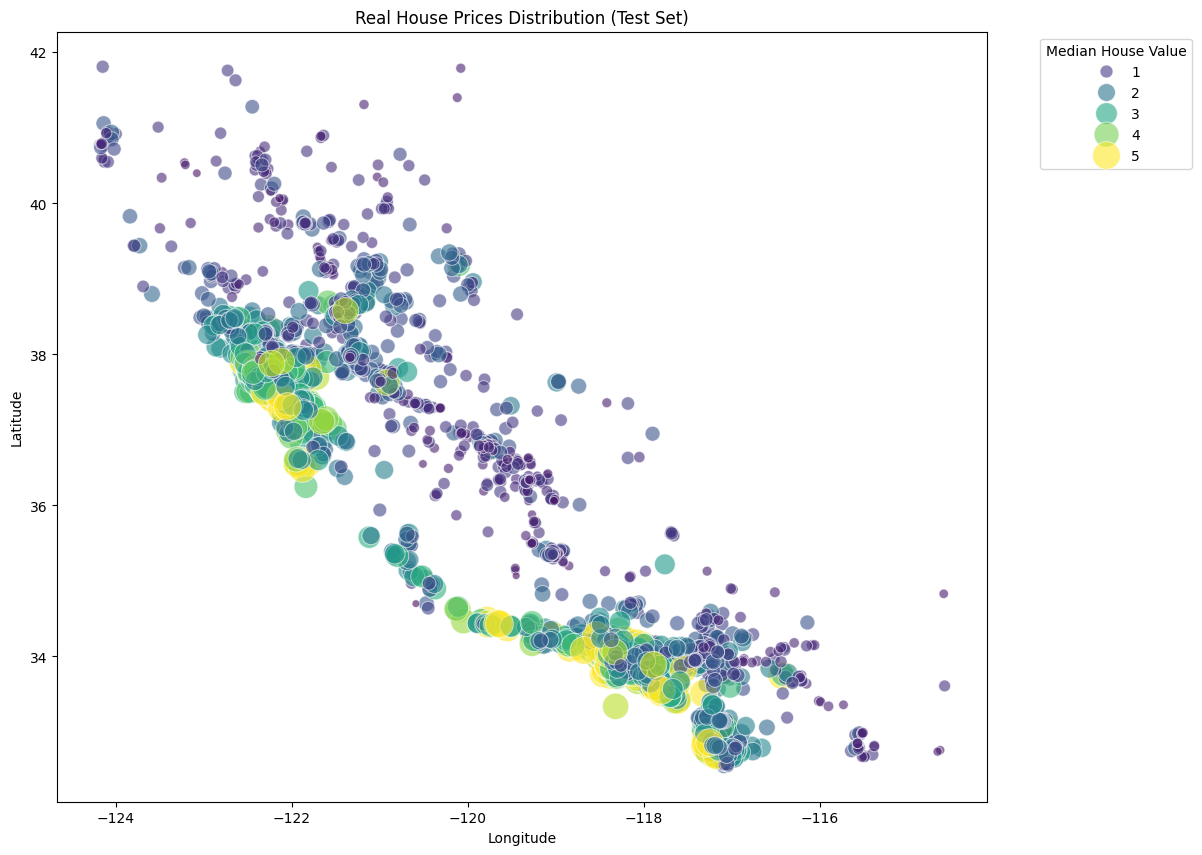

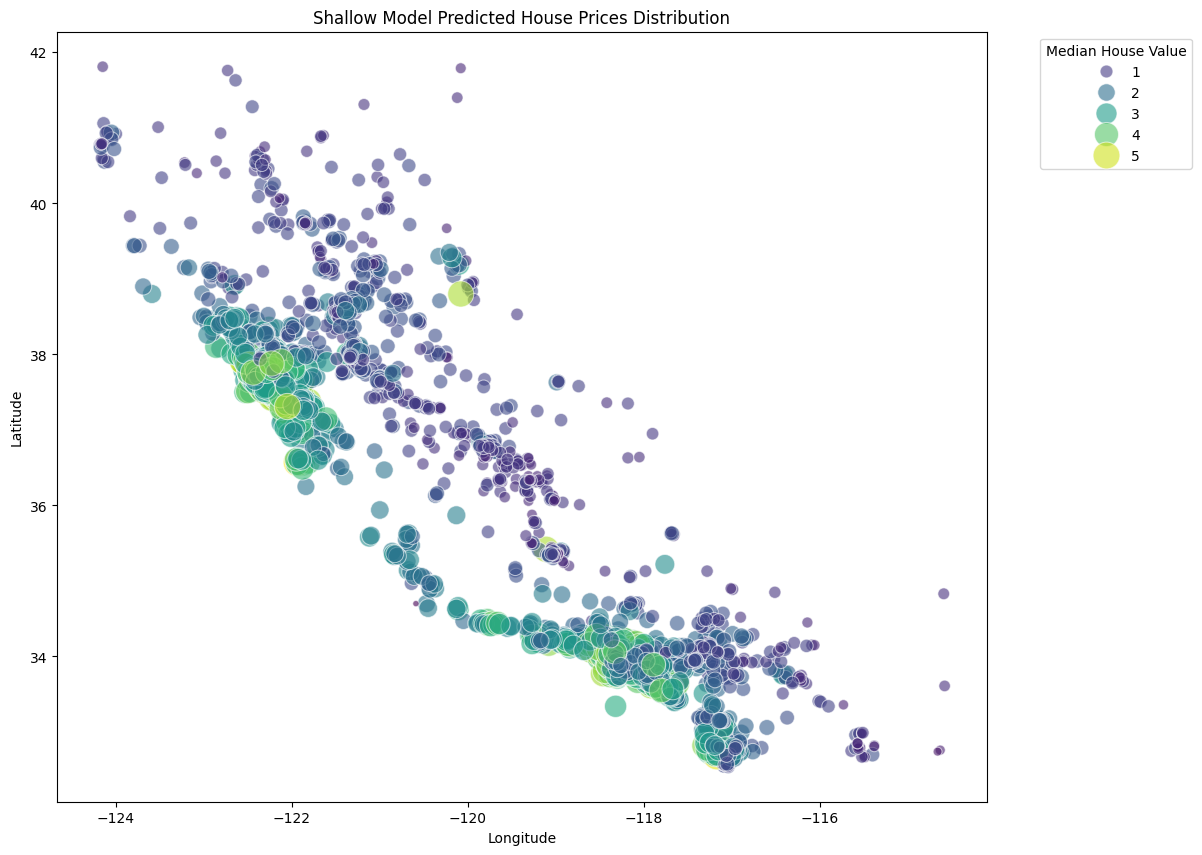

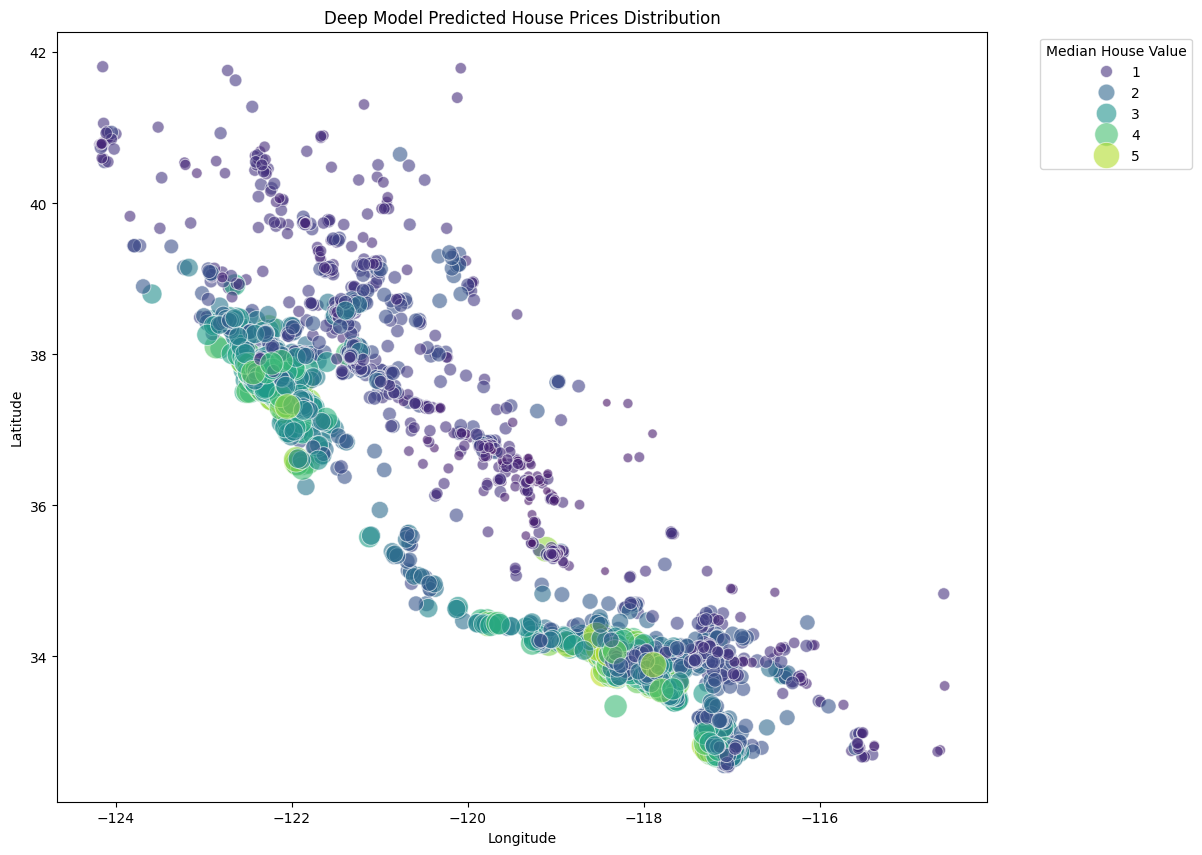

In [20]:
def plot_heatmap(latitude_data, longitude_data, price_data, title):
    plt.figure(figsize=(12, 10))
    sns.scatterplot(x=longitude_data, y=latitude_data, hue=price_data.flatten(),
                    palette='viridis', size=price_data.flatten(), sizes=(20, 400), alpha=0.6)
    plt.title(title)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend(title='Median House Value', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

# Plot real house prices on the test set
plot_heatmap(lat_test, lon_test, y_test.values, 'Real House Prices Distribution (Test Set)')

# Plot predicted house prices from the shallow model
plot_heatmap(lat_test, lon_test, y_pred_shallow, 'Shallow Model Predicted House Prices Distribution')

# Plot predicted house prices from the deep model
plot_heatmap(lat_test, lon_test, y_pred_deep, 'Deep Model Predicted House Prices Distribution')